In [1]:
#Creating a FASTA file
fasta_content = """>Gene_1 Homo sapiens insulin
ATGCCCCTGTGGATGCGCCTCCTGCCCCTGCTGGCGCTG
>Gene_2 Homo sapiens BRCA1
ATGCGTACGTAGCTAGCTAGCTAGCATGCGTACGTAG
>Gene_3 Mus musculus beta goblin
ATGGTGCACCTGACTCCTGAGGAGAAGTCTGCCGTT
>Gene_4 Homo sapiens TP53
ATGGAGGAGCCGCAGTCAGATCCTAGCAGAGCAAAATG
>Gene_5 Homo sapiens EGFR
ATGCGACCCTCCGGGACGGCCGGGGCAGCGCTGGTG
"""
file = open("genes.fasta", "w")
file.write(fasta_content)
file.close()
print("FASTA file created successfully!")

FASTA file created successfully!


In [3]:
#Reading a FASTA file with biopython
from Bio import SeqIO
for record in SeqIO.parse("genes.fasta", "fasta"):
    print(record.id)
    print(record.seq)
    print("---")


Gene_1
ATGCCCCTGTGGATGCGCCTCCTGCCCCTGCTGGCGCTG
---
Gene_2
ATGCGTACGTAGCTAGCTAGCTAGCATGCGTACGTAG
---
Gene_3
ATGGTGCACCTGACTCCTGAGGAGAAGTCTGCCGTT
---
Gene_4
ATGGAGGAGCCGCAGTCAGATCCTAGCAGAGCAAAATG
---
Gene_5
ATGCGACCCTCCGGGACGGCCGGGGCAGCGCTGGTG
---


In [5]:
#SeqRecord objects
from Bio import SeqIO
from Bio.SeqUtils import gc_fraction
for record in SeqIO.parse("genes.fasta", "fasta"):
    print("ID", record.id)
    print("Description", record.description)
    print("Sequence:", record.seq)
    print("Length:", len(record.seq))
    print("GC content:", gc_fraction(record.seq) * 100)
    print("---")
    

ID Gene_1
Description Gene_1 Homo sapiens insulin
Sequence: ATGCCCCTGTGGATGCGCCTCCTGCCCCTGCTGGCGCTG
Length: 39
GC content: 71.7948717948718
---
ID Gene_2
Description Gene_2 Homo sapiens BRCA1
Sequence: ATGCGTACGTAGCTAGCTAGCTAGCATGCGTACGTAG
Length: 37
GC content: 51.35135135135135
---
ID Gene_3
Description Gene_3 Mus musculus beta goblin
Sequence: ATGGTGCACCTGACTCCTGAGGAGAAGTCTGCCGTT
Length: 36
GC content: 55.55555555555556
---
ID Gene_4
Description Gene_4 Homo sapiens TP53
Sequence: ATGGAGGAGCCGCAGTCAGATCCTAGCAGAGCAAAATG
Length: 38
GC content: 52.63157894736842
---
ID Gene_5
Description Gene_5 Homo sapiens EGFR
Sequence: ATGCGACCCTCCGGGACGGCCGGGGCAGCGCTGGTG
Length: 36
GC content: 77.77777777777779
---


In [7]:
#Exercise 1
from Bio import SeqIO
from Bio.SeqUtils import gc_fraction
for record in SeqIO.parse("genes.fasta", "fasta"):
    GC = gc_fraction(record.seq) * 100
    if GC > 55:
        print("ID:", record.id)
        print("GC content:", GC)
        print("---")

ID: Gene_1
GC content: 71.7948717948718
---
ID: Gene_3
GC content: 55.55555555555556
---
ID: Gene_5
GC content: 77.77777777777779
---


In [8]:
#Exercise 2
from Bio import SeqIO
longest_length = 0
longest_id = ""
for record in SeqIO.parse("genes.fasta", "fasta"):
    print("ID", record.id)
    print("Length", len(record.seq))
    if len(record.seq) > longest_length:
        longest_length = len(record.seq)
        longest_id = record.id
print("Longest gene:", longest_id)
print("Length:", longest_length)

ID Gene_1
Length 39
ID Gene_2
Length 37
ID Gene_3
Length 36
ID Gene_4
Length 38
ID Gene_5
Length 36
Longest gene: Gene_1
Length: 39


In [2]:
#Creating a dataframe from Fasta sequences
from Bio import SeqIO
from Bio.SeqUtils import gc_fraction
import pandas as pd
gene_data = []
for record in SeqIO.parse("genes.fasta", "fasta"):
    gene_id = record.id
    length = len(record.seq)
    gc = round(gc_fraction(record.seq) * 100, 2)
    gene_data.append({"ID": gene_id, "Length": length, "GC_Content": gc})
df = pd.DataFrame(gene_data)
print(df)

       ID  Length  GC_Content
0  Gene_1      39       71.79
1  Gene_2      37       51.35
2  Gene_3      36       55.56
3  Gene_4      38       52.63
4  Gene_5      36       77.78


In [4]:
#Analyzing the DataFrame
from Bio import SeqIO
from Bio.SeqUtils import gc_fraction
import pandas as pd
gene_data = []
for record in SeqIO.parse("genes.fasta", "fasta"):
    gene_id = record.id
    length = len(record.seq)
    gc = round(gc_fraction(record.seq)* 100, 2)
    gene_data.append({"ID": gene_id, "Length": length, "GC_Content": gc})
df = pd.DataFrame(gene_data)
print(df)
#Sort by GC Content - highest first
print("Sorted by GC Content:")
print(df.sort_values("GC_Content", ascending=False))
print("---")
#Filter genes with GC content > 55
print("Genes with GC Content > 55:")
print(df[df["GC_Content"] > 55])
print("---")
#Basics Statistics
print("Basic Statistics:")
print(df.describe())

       ID  Length  GC_Content
0  Gene_1      39       71.79
1  Gene_2      37       51.35
2  Gene_3      36       55.56
3  Gene_4      38       52.63
4  Gene_5      36       77.78
Sorted by GC Content:
       ID  Length  GC_Content
4  Gene_5      36       77.78
0  Gene_1      39       71.79
2  Gene_3      36       55.56
3  Gene_4      38       52.63
1  Gene_2      37       51.35
---
Genes with GC Content > 55:
       ID  Length  GC_Content
0  Gene_1      39       71.79
2  Gene_3      36       55.56
4  Gene_5      36       77.78
---
Basic Statistics:
         Length  GC_Content
count   5.00000    5.000000
mean   37.20000   61.822000
std     1.30384   12.118035
min    36.00000   51.350000
25%    36.00000   52.630000
50%    37.00000   55.560000
75%    38.00000   71.790000
max    39.00000   77.780000


In [5]:
#Saving the dataframe in CSV
df.to_csv("gene_analysis.csv", index=False)
print("File saved successfully!")
#Read it back to confirm
df_check = pd.read_csv("gene_analysis.csv")
print(df_check)

File saved successfully!
       ID  Length  GC_Content
0  Gene_1      39       71.79
1  Gene_2      37       51.35
2  Gene_3      36       55.56
3  Gene_4      38       52.63
4  Gene_5      36       77.78


In [6]:
#Exercise 1:
from Bio import SeqIO
from Bio.SeqUtils import gc_fraction
import pandas as pd
gene_data = []
for record in SeqIO.parse("genes.fasta", "fasta"):
    gene_id = record.id
    length = len(record.seq)
    gc = round(gc_fraction(record.seq) * 100, 2)
    species = record.description.split()[1] + " " + record.description.split()[2]
    gene_data.append({"ID": gene_id, "Length": length, "GC_Content": gc, "Species": species})
df = pd.DataFrame(gene_data)
print(df)


       ID  Length  GC_Content       Species
0  Gene_1      39       71.79  Homo sapiens
1  Gene_2      37       51.35  Homo sapiens
2  Gene_3      36       55.56  Mus musculus
3  Gene_4      38       52.63  Homo sapiens
4  Gene_5      36       77.78  Homo sapiens


In [7]:
#Exercise 2:
from Bio import SeqIO
from Bio.SeqUtils import gc_fraction
import pandas as pd
gene_data = []
for record in SeqIO.parse("genes.fasta", "fasta"):
    gene_id = record.id
    length = len(record.seq)
    gc = round(gc_fraction(record.seq) * 100, 2)
    gene_data.append({"ID": gene_id, "Length": length, "GC_Content": gc})
df = pd.DataFrame(gene_data)
print("Sorted by GC Content:")
print(df.sort_values("GC_Content", ascending=True).iloc[0])
print("Average length:")
print(df["Length"].mean())
print("Genes with length > 36:")
print(df[df["Length"] > 36])
print("---")
df[df["Length"]>36].to_csv("long_genes.csv", index=False)
print("File saved successfully!")
df_check = pd.read_csv("long_genes.csv")
print(df_check)


Sorted by GC Content:
ID            Gene_2
Length            37
GC_Content     51.35
Name: 1, dtype: object
Average length:
37.2
Genes with length > 36:
       ID  Length  GC_Content
0  Gene_1      39       71.79
1  Gene_2      37       51.35
3  Gene_4      38       52.63
---
File saved successfully!
       ID  Length  GC_Content
0  Gene_1      39       71.79
1  Gene_2      37       51.35
2  Gene_4      38       52.63


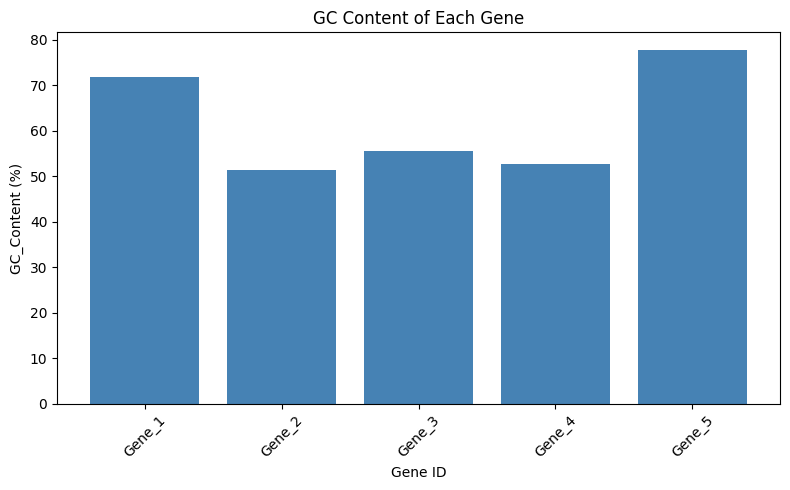

In [7]:
#Bar chart of GC content for each genes
import matplotlib.pyplot as plt
plt.figure(figsize = (8, 5))
plt.bar(df["ID"], df["GC_Content"], color = "steelblue")
plt.title("GC Content of Each Gene")
plt.xlabel("Gene ID")
plt.ylabel("GC_Content (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [8]:
from Bio import SeqIO
from Bio.SeqUtils import gc_fraction
import pandas as pd
import matplotlib.pyplot as plt
gene_data = []
for record in SeqIO.parse("genes.fasta", "fasta"):
    gene_id = record.id
    length = len(record.seq)
    gc = round(gc_fraction(record.seq)*100, 2)
    gene_data.append({"ID": gene_id, "Length": length, "GC_Content": gc})
df = pd.DataFrame(gene_data)
print(df)    


       ID  Length  GC_Content
0  Gene_1      39       71.79
1  Gene_2      37       51.35
2  Gene_3      36       55.56
3  Gene_4      38       52.63
4  Gene_5      36       77.78


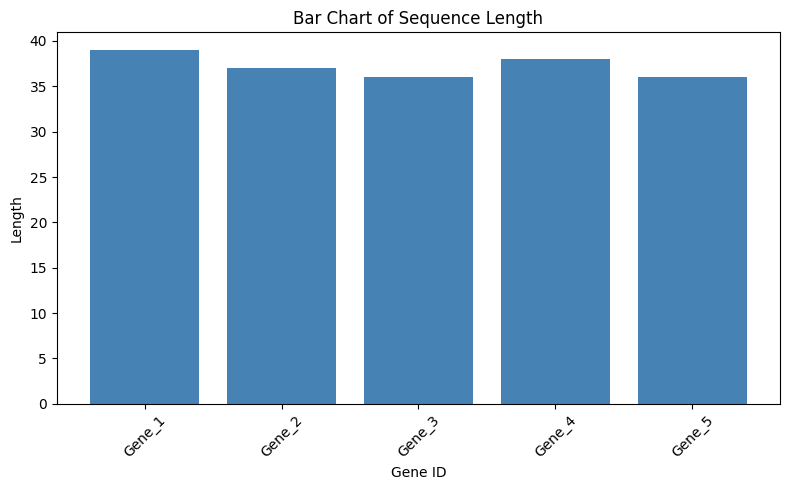

In [10]:
#Bar Chart of sequence lengths
import matplotlib.pyplot as plt
plt.figure(figsize= (8, 5))
plt.bar(df["ID"], df["Length"], color = "steelblue")
plt.title("Bar Chart of Sequence Length")
plt.xlabel("Gene ID")
plt.ylabel("Length")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

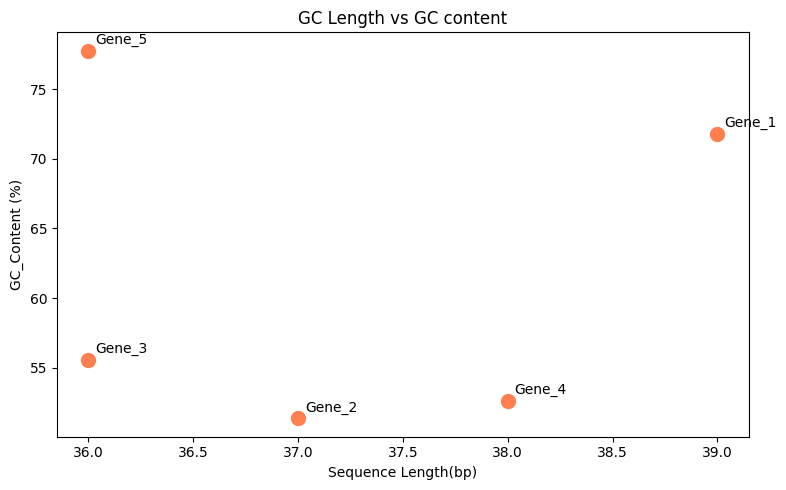

In [11]:
#Scatter plot: Length vs GC content
import matplotlib.pyplot as plt
plt.figure(figsize = (8,5))
plt.scatter(df["Length"], df["GC_Content"], color = "coral", s = 100)
for i, row in df.iterrows():
    plt.annotate(row["ID"], (row["Length"], row["GC_Content"]), textcoords = "offset points", xytext = (5, 5))
plt.title("GC Length vs GC content")
plt.xlabel("Sequence Length(bp)")
plt.ylabel("GC_Content (%)")
plt.tight_layout()
plt.show()
    

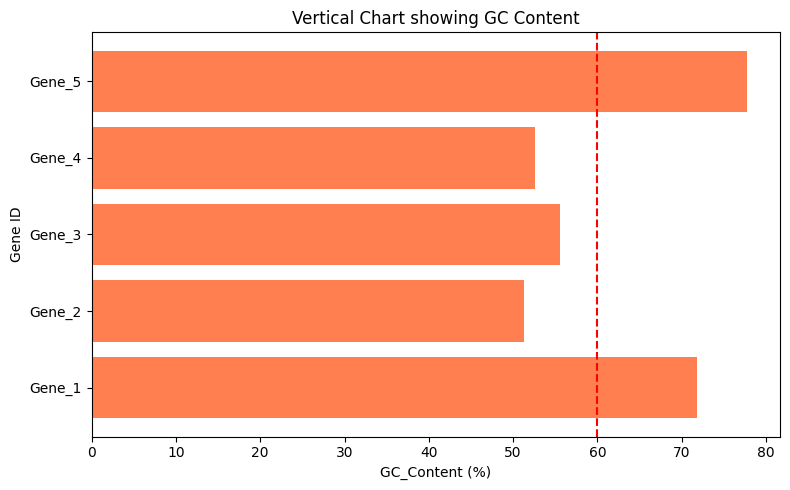

In [13]:
#Exercise 1:
import matplotlib.pyplot as plt
plt.figure(figsize = (8,5))
plt.barh(df["ID"], df["GC_Content"], color = "coral")
plt.axvline(x=60, color = "red", linestyle = "--")
plt.title("Vertical Chart showing GC Content")
plt.ylabel("Gene ID")
plt.xlabel("GC_Content (%)")
plt.tight_layout()
plt.show()

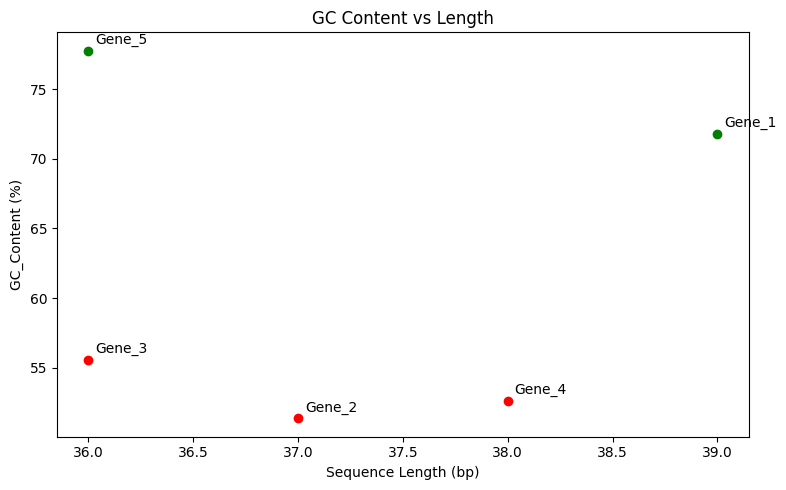

In [16]:
#Exercise 2:
import matplotlib.pyplot as plt
high_gc = df[df["GC_Content"] > 60]
low_gc = df[df["GC_Content"] <= 60]
plt.figure(figsize = (8,5))
plt.scatter(high_gc["Length"], high_gc["GC_Content"], color = "green")
plt.scatter(low_gc["Length"], low_gc["GC_Content"], color = "red")
for i, row in df.iterrows():
    plt.annotate(row["ID"], (row["Length"], row["GC_Content"]), textcoords = "offset points", xytext = (5,5))
plt.title("GC Content vs Length")
plt.xlabel("Sequence Length (bp)")
plt.ylabel("GC_Content (%)")
plt.tight_layout()
plt.show()